
# Hospital Patient & Healthcare Analytics
### Healthcare Operations, Revenue & Patient Risk Analysis

**Objective:** Analyze hospital admissions data to identify trends in patient demographics, department performance, revenue, length of stay, patient satisfaction, and 30-day readmissions. The workflow covers data loading, quality validation, exploratory analysis, KPI analysis, visualization, and interpretable predictive modeling.

**Dataset:** `hospital_admissions_data.csv` — 13,266 admission records and 14 features covering department, diagnosis, age, insurance, length of stay, billing, discharge status, 30-day readmission, and patient satisfaction.

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn


## 1. Setup & Data Loading

In [1]:

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)
matches = [f for f in csv_files if "hospital" in os.path.basename(f).lower() and "admission" in os.path.basename(f).lower()]

if not matches:
    raise FileNotFoundError("Hospital admissions CSV not found under /kaggle/input.")

csv_path = matches[0]
df = pd.read_csv(csv_path, parse_dates=["admission_date"])

if not pd.api.types.is_bool_dtype(df["is_readmission_30d"]):
    df["is_readmission_30d"] = (
        df["is_readmission_30d"]
        .astype(str).str.strip().str.lower()
        .map({"true": True, "false": False, "1": True, "0": False, "yes": True, "no": False})
    )

df["admission_date"] = pd.to_datetime(df["admission_date"], errors="coerce")

print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")
df.head()


Loaded: /kaggle/input/datasets/hifitaekn/hospital-admissions-data/hospital_admissions_data.csv
Shape: (13266, 14)


,admission_id,patient_id,admission_date,department,diagnosis,age,gender,insurance_type,admission_type,length_of_stay_days,billing_amount,discharge_status,is_readmission_30d,patient_satisfaction
0,ADM306377,PT24506,2024-01-01,General Medicine,Diabetes Mellitus,69,Male,Corporate Insurance,Referral,5,"35,516.43",Recovered,False,5.00
1,ADM304754,PT23379,2024-01-01,General Medicine,Viral Fever,58,Female,Self-Pay,Emergency,5,"37,382.32",Recovered,False,4.00
2,ADM311557,PT28133,2024-01-01,Gynecology,C-Section,34,Male,Self-Pay,Elective,5,"41,269.39",Recovered,False,2.00
3,ADM309559,PT26701,2024-01-01,Cardiology,Hypertension,72,Male,Self-Pay,Referral,2,"64,657.99",Recovered,False,3.00
4,ADM300616,PT20457,2024-01-01,Emergency,Acute Abdomen,60,Female,Corporate Insurance,Elective,4,"27,881.82",Recovered,False,5.00


## 2. Dataset Structure

In [2]:

schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct": (df.isna().mean().mul(100)).round(2).values,
    "unique_values": df.nunique(dropna=True).values
})

schema


,column,dtype,missing,missing_pct,unique_values
0,admission_id,object,0,0.00,13266
1,patient_id,object,0,0.00,8436
2,admission_date,datetime64[ns],0,0.00,731
3,department,object,0,0.00,10
4,diagnosis,object,0,0.00,37
5,age,int64,0,0.00,96
6,gender,object,0,0.00,2
7,insurance_type,object,0,0.00,4
8,admission_type,object,0,0.00,3
9,length_of_stay_days,int64,0,0.00,19


In [3]:

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])
print("Duplicate rows:", f"{df.duplicated().sum():,}")
print("Duplicate admission IDs:", f"{df['admission_id'].duplicated().sum():,}")


Rows: 13,266
Columns: 14
Duplicate rows: 0
Duplicate admission IDs: 0


## 3. Data Quality Checks

In [4]:

quality = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
}).sort_values(["missing_count", "unique_values"], ascending=[False, True])

quality


,missing_count,missing_pct,unique_values
patient_satisfaction,255,1.92,5
gender,0,0.00,2
is_readmission_30d,0,0.00,2
admission_type,0,0.00,3
insurance_type,0,0.00,4
discharge_status,0,0.00,4
department,0,0.00,10
length_of_stay_days,0,0.00,19
diagnosis,0,0.00,37
age,0,0.00,96


In [5]:

quality_flags = {
    "negative_age": int((df["age"] < 0).sum()),
    "invalid_los": int((df["length_of_stay_days"] < 0).sum()),
    "negative_billing": int((df["billing_amount"] < 0).sum()),
    "invalid_readmission_flag": int(df["is_readmission_30d"].isna().sum())
}

pd.Series(quality_flags, name="count").to_frame()


,count
negative_age,0
invalid_los,0
negative_billing,0
invalid_readmission_flag,0


In [6]:
satisfaction_check = (
    df.groupby("discharge_status", dropna=False)
      .agg(
          count=("patient_satisfaction", "count"),
          mean=("patient_satisfaction", "mean"),
          missing=("patient_satisfaction", lambda x: x.isna().sum())
      )
)

satisfaction_check

,count,mean,missing
discharge_status,,,
Deceased,54,3.15,255
Left Against Medical Advice,370,3.84,0
Recovered,11867,3.76,0
Transferred,720,3.68,0


## 4. Hospital KPI Overview

In [7]:

total_admissions = len(df)
unique_patients = df["patient_id"].nunique()
total_revenue = df["billing_amount"].sum()
avg_los = df["length_of_stay_days"].mean()
readmission_rate = df["is_readmission_30d"].mean() * 100
avg_satisfaction = df["patient_satisfaction"].mean()

print(f"Total Admissions : {total_admissions:,.0f}")
print(f"Unique Patients  : {unique_patients:,.0f}")
print(f"Total Revenue    : ₹{total_revenue:,.0f}")
print(f"Average LOS      : {avg_los:.2f} days")
print(f"30-Day Readmission: {readmission_rate:.2f}%")
print(f"Avg Satisfaction : {avg_satisfaction:.2f} / 5")


Total Admissions : 13,266
Unique Patients  : 8,436
Total Revenue    : ₹1,130,868,407
Average LOS      : 4.57 days
30-Day Readmission: 10.60%
Avg Satisfaction : 3.76 / 5


## 5. Monthly Admissions & Revenue Trend

In [8]:

monthly = (
    df.set_index("admission_date")
      .resample("MS")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum"),
          avg_billing=("billing_amount", "mean")
      )
)

monthly["revenue_growth_pct"] = monthly["revenue"].pct_change().mul(100)
monthly


,admissions,revenue,avg_billing,revenue_growth_pct
admission_date,,,,
2024-01-01,618,"54,007,672.04","87,391.06",NaN
2024-02-01,667,"55,358,369.80","82,996.06",2.50
2024-03-01,520,"43,921,261.90","84,463.97",-20.66
2024-04-01,532,"46,242,976.75","86,922.89",5.29
2024-05-01,478,"40,645,910.53","85,033.29",-12.10
2024-06-01,490,"41,334,066.62","84,355.24",1.69
2024-07-01,609,"53,526,324.15","87,892.16",29.50
2024-08-01,612,"51,962,262.35","84,905.66",-2.92
2024-09-01,580,"47,448,568.89","81,807.88",-8.69


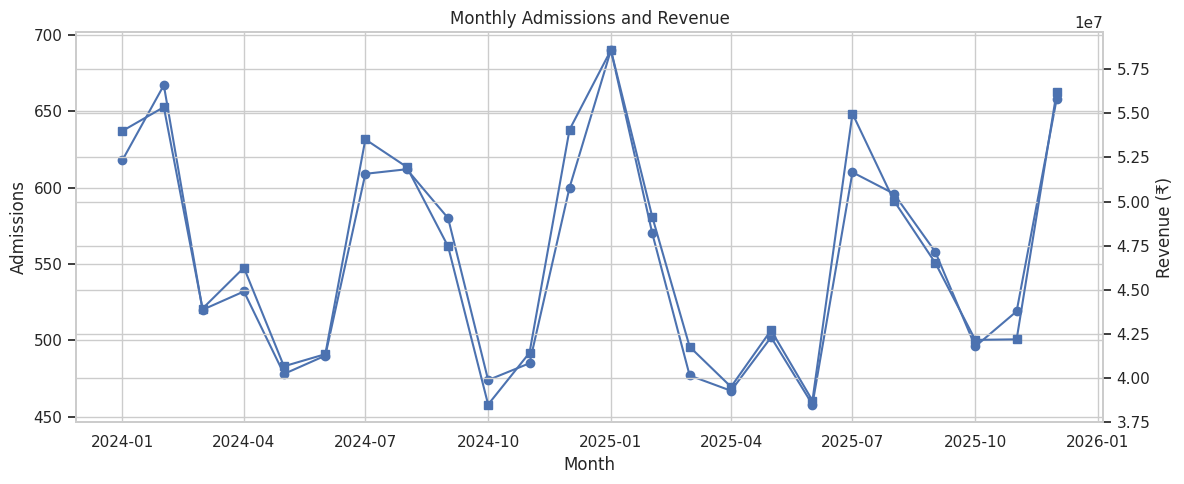

In [9]:

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly.index, monthly["admissions"], marker="o", label="Admissions")
ax1.set_ylabel("Admissions")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["revenue"], marker="s", label="Revenue")
ax2.set_ylabel("Revenue (₹)")

ax1.set_title("Monthly Admissions and Revenue")
fig.tight_layout()
plt.show()


## 6. Department Performance

In [10]:

dept = (
    df.groupby("department")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum"),
          avg_billing=("billing_amount", "mean"),
          avg_los=("length_of_stay_days", "mean"),
          readmission_rate=("is_readmission_30d", "mean"),
          avg_satisfaction=("patient_satisfaction", "mean")
      )
)

dept["revenue_per_admission"] = dept["revenue"] / dept["admissions"]
dept["readmission_rate"] = dept["readmission_rate"] * 100
dept.sort_values("revenue", ascending=False)


,admissions,revenue,avg_billing,avg_los,readmission_rate,avg_satisfaction,revenue_per_admission
department,,,,,,,
Oncology,1082,"238,407,547.26","220,339.69",8.54,9.98,3.70,"220,339.69"
Orthopedics,1586,"208,411,023.86","131,406.70",6.42,10.03,3.80,"131,406.70"
Cardiology,1708,"191,326,604.59","112,017.92",5.13,10.77,3.78,"112,017.92"
Neurology,1199,"128,638,705.85","107,288.33",6.26,10.76,3.76,"107,288.33"
General Medicine,2089,"90,190,273.29","43,173.90",3.21,11.01,3.75,"43,173.90"
Emergency,1880,"71,658,985.06","38,116.48",2.21,10.64,3.74,"38,116.48"
Gynecology,1157,"65,166,905.37","56,324.03",3.27,10.54,3.78,"56,324.03"
Nephrology,690,"61,676,012.39","89,385.53",5.32,10.14,3.73,"89,385.53"
Pediatrics,1328,"45,829,138.64","34,509.89",3.19,10.47,3.76,"34,509.89"


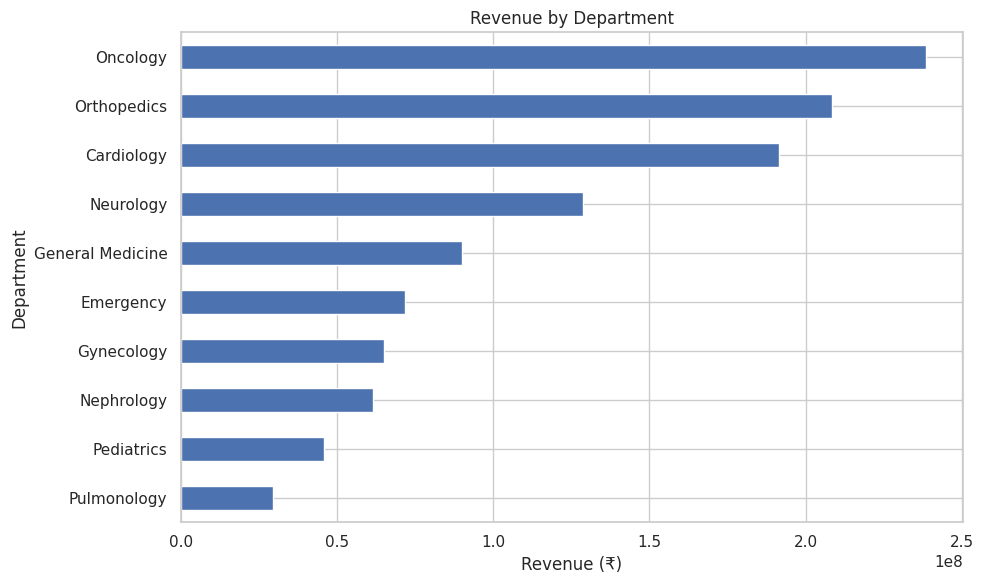

In [11]:

fig, ax = plt.subplots(figsize=(10, 6))
dept["revenue"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Revenue by Department")
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("Department")
plt.tight_layout()
plt.show()


## 7. Readmission by Department

In [12]:

readmit_dept = (
    df.groupby("department")
      .agg(
          admissions=("admission_id", "count"),
          readmission_rate=("is_readmission_30d", "mean")
      )
      .sort_values("readmission_rate", ascending=False)
)

readmit_dept["readmission_rate"] *= 100
readmit_dept


,admissions,readmission_rate
department,,
Pulmonology,547,11.88
General Medicine,2089,11.01
Cardiology,1708,10.77
Neurology,1199,10.76
Emergency,1880,10.64
Gynecology,1157,10.54
Pediatrics,1328,10.47
Nephrology,690,10.14
Orthopedics,1586,10.03


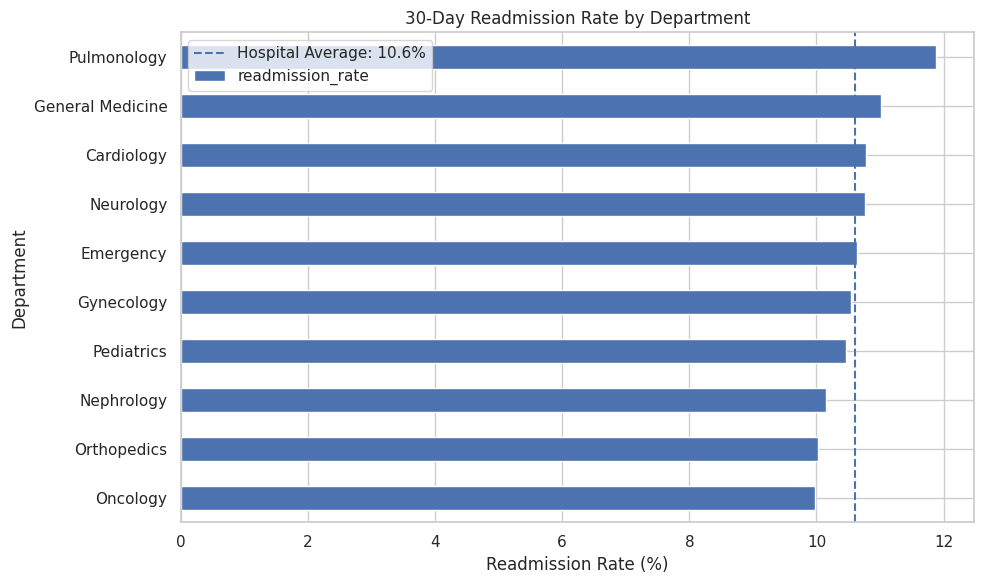

In [13]:

fig, ax = plt.subplots(figsize=(10, 6))
readmit_dept["readmission_rate"].sort_values().plot(kind="barh", ax=ax)
ax.axvline(readmission_rate, linestyle="--", label=f"Hospital Average: {readmission_rate:.1f}%")
ax.set_title("30-Day Readmission Rate by Department")
ax.set_xlabel("Readmission Rate (%)")
ax.set_ylabel("Department")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Patient Demographics

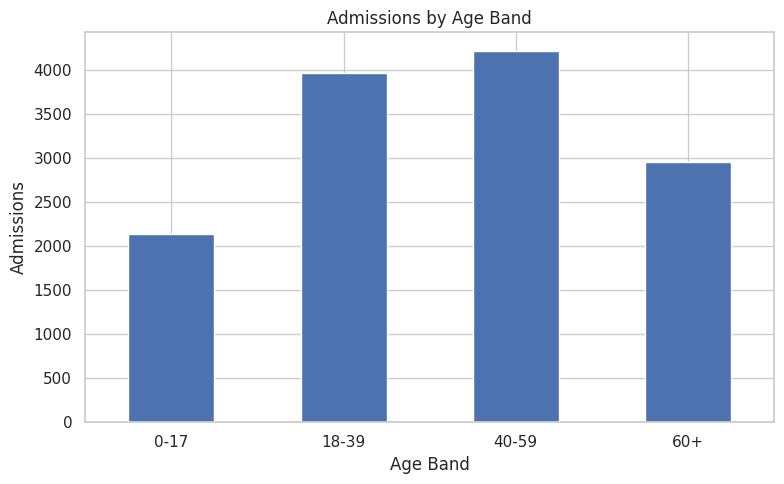

In [14]:

age_bins = [0, 18, 40, 60, np.inf]
age_labels = ["0-17", "18-39", "40-59", "60+"]

df["age_band"] = pd.cut(
    df["age"], bins=age_bins, labels=age_labels, right=False
)

age_dist = df["age_band"].value_counts().reindex(age_labels)

fig, ax = plt.subplots(figsize=(8, 5))
age_dist.plot(kind="bar", ax=ax)
ax.set_title("Admissions by Age Band")
ax.set_xlabel("Age Band")
ax.set_ylabel("Admissions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:

demo = pd.DataFrame({
    "gender": df["gender"].value_counts(),
    "insurance_type": df["insurance_type"].value_counts()
})

demo


,gender,insurance_type
Corporate Insurance,NaN,"2,335.00"
Female,"6,245.00",NaN
Government Scheme,NaN,"3,744.00"
Male,"7,021.00",NaN
Private Insurance,NaN,"4,551.00"
Self-Pay,NaN,"2,636.00"


## 9. Revenue by Insurance Type

In [16]:

insurance = (
    df.groupby("insurance_type")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum"),
          avg_billing=("billing_amount", "mean")
      )
      .sort_values("revenue", ascending=False)
)

insurance["revenue_share_pct"] = insurance["revenue"] / insurance["revenue"].sum() * 100
insurance


,admissions,revenue,avg_billing,revenue_share_pct
insurance_type,,,,
Private Insurance,4551,"383,092,341.18","84,177.62",33.88
Government Scheme,3744,"320,046,493.55","85,482.50",28.30
Self-Pay,2636,"225,669,577.34","85,610.61",19.96
Corporate Insurance,2335,"202,059,995.30","86,535.33",17.87


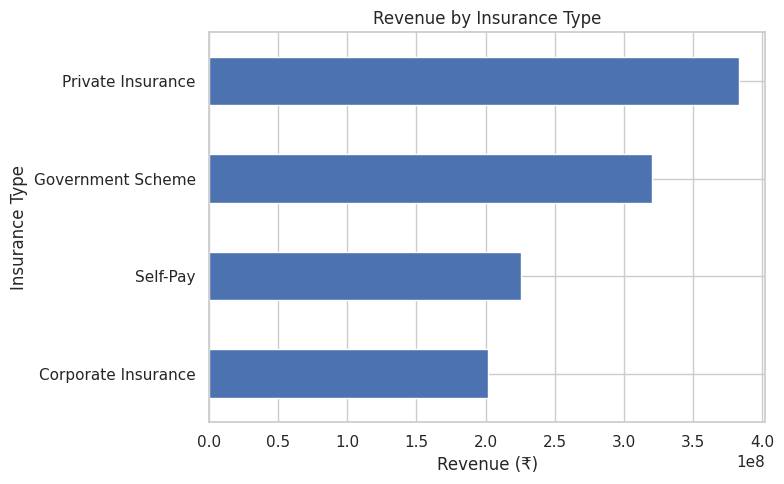

In [17]:

fig, ax = plt.subplots(figsize=(8, 5))
insurance["revenue"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Revenue by Insurance Type")
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("Insurance Type")
plt.tight_layout()
plt.show()


## 10. Length of Stay & Patient Satisfaction

In [18]:

los_bins = [0, 2, 5, 10, np.inf]
los_labels = ["1-2 days", "3-5 days", "6-10 days", "10+ days"]

df["los_band"] = pd.cut(
    df["length_of_stay_days"], bins=los_bins, labels=los_labels, right=True
)

sat_by_los = (
    df.groupby("los_band", observed=True)["patient_satisfaction"]
      .agg(["count", "mean"])
)

sat_by_los


,count,mean
los_band,,
1-2 days,3448,3.73
3-5 days,5358,3.77
6-10 days,3704,3.77
10+ days,501,3.72


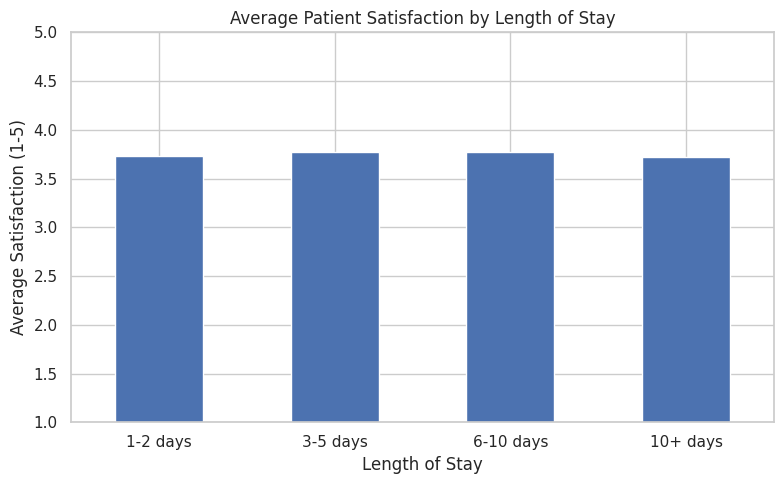

In [19]:

fig, ax = plt.subplots(figsize=(8, 5))
sat_by_los["mean"].plot(kind="bar", ax=ax)
ax.set_title("Average Patient Satisfaction by Length of Stay")
ax.set_xlabel("Length of Stay")
ax.set_ylabel("Average Satisfaction (1-5)")
ax.set_ylim(1, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Diagnosis & Discharge Analysis

In [20]:

diagnosis_summary = (
    df.groupby("diagnosis")
      .agg(
          admissions=("admission_id", "count"),
          revenue=("billing_amount", "sum"),
          avg_los=("length_of_stay_days", "mean"),
          readmission_rate=("is_readmission_30d", "mean")
      )
      .sort_values("admissions", ascending=False)
)

diagnosis_summary["readmission_rate"] *= 100
diagnosis_summary.head(10)


,admissions,revenue,avg_los,readmission_rate
diagnosis,,,,
Hypertension,975,"73,378,079.28",4.14,11.79
Viral Fever,873,"34,397,661.58",3.24,10.77
Diabetes Mellitus,552,"23,950,651.59",3.18,11.96
Gastroenteritis,506,"21,814,433.87",3.16,10.67
Trauma,492,"18,694,912.74",2.29,11.38
Accident Injury,486,"18,373,621.68",2.14,10.49
Acute Abdomen,467,"17,586,382.39",2.22,9.85
Heart Failure,443,"49,051,854.79",5.00,9.93
Poisoning,435,"17,004,068.25",2.18,10.80


In [21]:

discharge_summary = (
    df.groupby("discharge_status")
      .agg(
          admissions=("admission_id", "count"),
          avg_billing=("billing_amount", "mean"),
          avg_los=("length_of_stay_days", "mean"),
          avg_satisfaction=("patient_satisfaction", "mean")
      )
      .sort_values("admissions", ascending=False)
)

discharge_summary


,admissions,avg_billing,avg_los,avg_satisfaction
discharge_status,,,,
Recovered,11867,"85,380.99",4.60,3.76
Transferred,720,"84,721.32",4.60,3.68
Left Against Medical Advice,370,"86,292.82",4.59,3.84
Deceased,309,"80,014.67",3.39,3.15



## 12. 30-Day Readmission Risk Model

A logistic regression model is used as an interpretable baseline. Features are limited to information available around discharge; outcome-derived fields such as discharge status and patient satisfaction are excluded to reduce leakage risk.


In [22]:

target = "is_readmission_30d"

categorical_features = [
    "department",
    "diagnosis",
    "insurance_type",
    "admission_type",
    "gender"
]

numeric_features = [
    "age",
    "length_of_stay_days",
    "billing_amount"
]

model_df = df[categorical_features + numeric_features + [target]].copy()
model_df = model_df.dropna(subset=[target])

X = model_df[categorical_features + numeric_features]
y = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.50).astype(int)

auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")
print(f"Average Precision: {ap:.3f}")
print()
print(classification_report(
    y_test, y_pred,
    target_names=["No Readmission", "Readmission"],
    digits=3
))


ROC-AUC: 0.804
Average Precision: 0.264

                precision    recall  f1-score   support

No Readmission      0.983     0.588     0.735      2965
   Readmission      0.208     0.915     0.339       352

      accuracy                          0.622      3317
     macro avg      0.596     0.751     0.537      3317
  weighted avg      0.901     0.622     0.693      3317



## 13. Model Evaluation

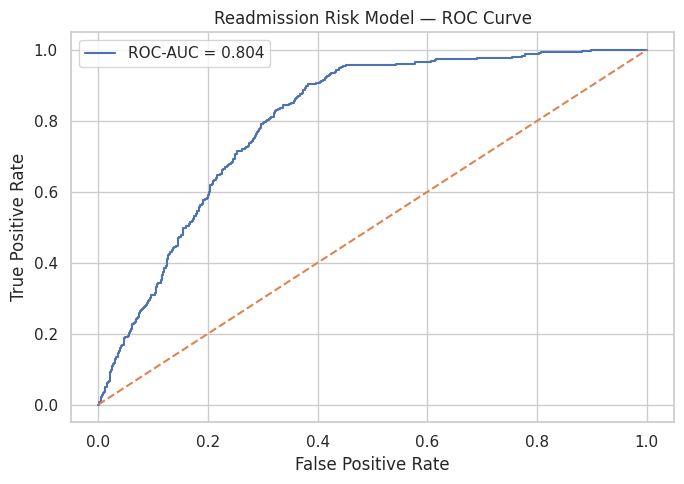

In [23]:

fig, ax = plt.subplots(figsize=(7, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)

ax.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Readmission Risk Model — ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()


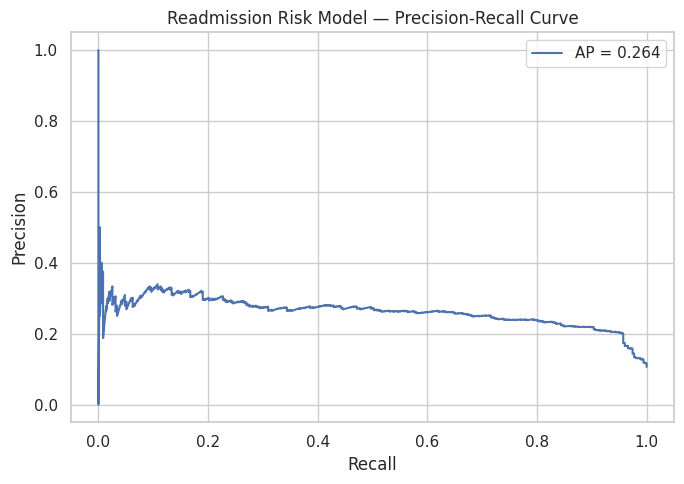

In [24]:

fig, ax = plt.subplots(figsize=(7, 5))
precision, recall, _ = precision_recall_curve(y_test, y_prob)

ax.plot(recall, precision, label=f"AP = {ap:.3f}")
ax.set_title("Readmission Risk Model — Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()


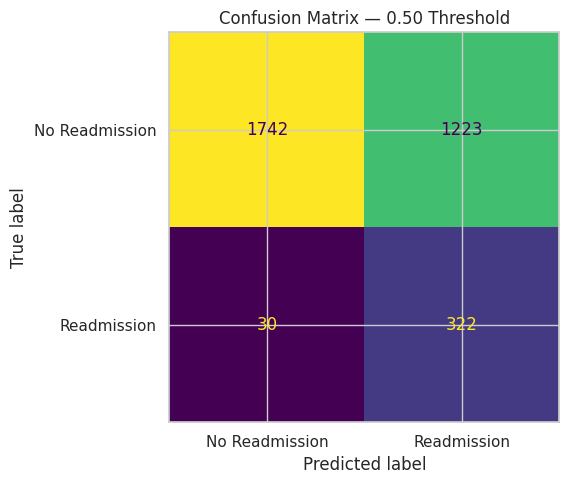

In [25]:

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "Readmission"]
).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — 0.50 Threshold")
plt.tight_layout()
plt.show()


### Threshold Analysis

In [26]:

thresholds = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for threshold in thresholds:
    pred = (y_prob >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm_t.ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table.round(3)


,threshold,precision,recall,false_positives,false_negatives
0,0.20,0.20,0.95,1326,16
1,0.25,0.20,0.95,1322,17
2,0.30,0.20,0.95,1315,17
3,0.35,0.20,0.95,1312,18
4,0.40,0.20,0.94,1295,20
5,0.45,0.21,0.94,1262,23
6,0.50,0.21,0.92,1223,30
7,0.55,0.22,0.89,1116,40
8,0.60,0.23,0.82,952,63
9,0.65,0.25,0.71,748,101


## 14. Readmission Risk Drivers

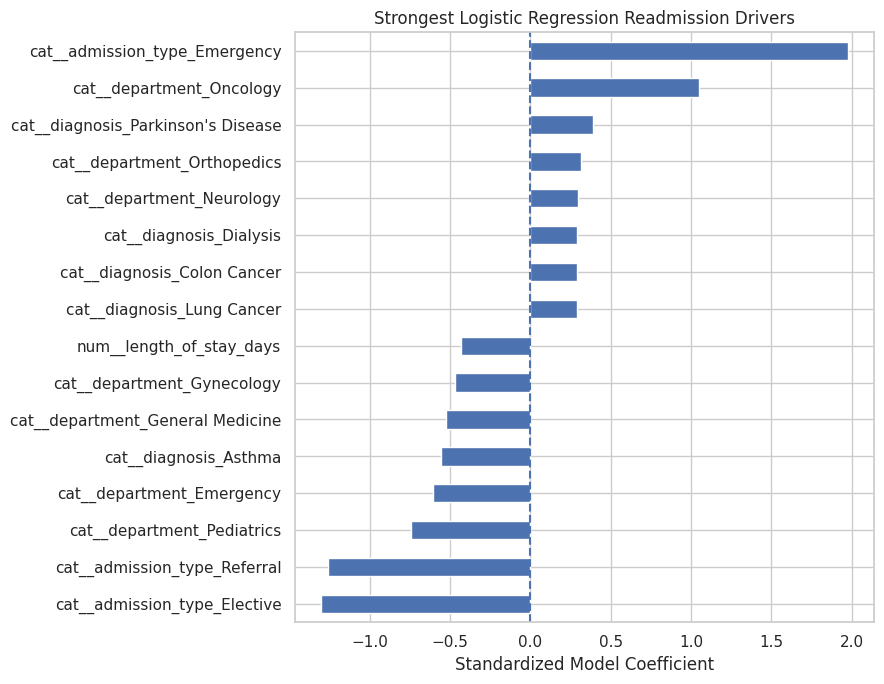

In [27]:

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

importance = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .sort_values("coefficient")
)

top_features = pd.concat([
    importance.head(8),
    importance.tail(8)
]).drop_duplicates()

fig, ax = plt.subplots(figsize=(9, 7))
top_features.plot(
    x="feature",
    y="coefficient",
    kind="barh",
    ax=ax,
    legend=False
)
ax.axvline(0, linestyle="--")
ax.set_title("Strongest Logistic Regression Readmission Drivers")
ax.set_xlabel("Standardized Model Coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 15. Actionable Insights

In [28]:

top_revenue_dept = dept["revenue"].idxmax()
top_volume_dept = dept["admissions"].idxmax()
highest_readmit_dept = readmit_dept["readmission_rate"].idxmax()
lowest_satisfaction_band = sat_by_los["mean"].idxmin()
peak_month = monthly["admissions"].idxmax()

print("Key Findings")
print("-" * 60)
print(f"Highest-revenue department: {top_revenue_dept}")
print(f"Highest-admission-volume department: {top_volume_dept}")
print(f"Highest readmission-rate department: {highest_readmit_dept}")
print(f"Lowest-satisfaction LOS band: {lowest_satisfaction_band}")
print(f"Peak admission month: {peak_month.strftime('%B %Y')}")
print(f"Hospital 30-day readmission rate: {readmission_rate:.2f}%")
print(f"Readmission model ROC-AUC: {auc:.3f}")

print("\nRecommended Actions")
print("-" * 60)
print("1. Review departments with above-average 30-day readmission rates.")
print("2. Use monthly admission trends for staffing and capacity planning.")
print("3. Investigate long-stay cohorts with lower satisfaction.")
print("4. Use the risk model as a decision-support baseline for discharge follow-up.")


Key Findings
------------------------------------------------------------
Highest-revenue department: Oncology
Highest-admission-volume department: General Medicine
Highest readmission-rate department: Pulmonology
Lowest-satisfaction LOS band: 10+ days
Peak admission month: January 2025
Hospital 30-day readmission rate: 10.60%
Readmission model ROC-AUC: 0.804

Recommended Actions
------------------------------------------------------------
1. Review departments with above-average 30-day readmission rates.
2. Use monthly admission trends for staffing and capacity planning.
3. Investigate long-stay cohorts with lower satisfaction.
4. Use the risk model as a decision-support baseline for discharge follow-up.


## 16. Export Analytics for Power BI

In [29]:

export_dir = "/kaggle/working/hospital_analytics_exports"
os.makedirs(export_dir, exist_ok=True)

df.to_csv(f"{export_dir}/hospital_admissions_clean.csv", index=False)
monthly.reset_index().to_csv(f"{export_dir}/monthly_kpis.csv", index=False)
dept.reset_index().to_csv(f"{export_dir}/department_kpis.csv", index=False)
insurance.reset_index().to_csv(f"{export_dir}/insurance_kpis.csv", index=False)
readmit_dept.reset_index().to_csv(f"{export_dir}/department_readmission.csv", index=False)
diagnosis_summary.reset_index().to_csv(f"{export_dir}/diagnosis_summary.csv", index=False)

print(f"Exported analytics tables to: {export_dir}")
print("\nFiles:")
for file in sorted(os.listdir(export_dir)):
    print(" -", file)


Exported analytics tables to: /kaggle/working/hospital_analytics_exports

Files:
 - department_kpis.csv
 - department_readmission.csv
 - diagnosis_summary.csv
 - hospital_admissions_clean.csv
 - insurance_kpis.csv
 - monthly_kpis.csv



## 17. Analyst Takeaway

This project demonstrates an end-to-end healthcare analytics workflow: **data ingestion → quality validation → KPI analysis → trend analysis → segmentation → visualization → predictive modeling → actionable recommendations → Power BI-ready exports**.

The strongest analyst skills demonstrated here are **Python/Pandas, data quality, EDA, KPI design, SQL-ready data preparation, visualization, and business-oriented interpretation**.
